In [35]:
# Import modules
import rdkit
from IPython.display import SVG
from notebook_utils import draw_molecule
from rdkit.Chem import Descriptors
from rdkit.Chem.Lipinski import rdMolDescriptors

# Print versions
print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.1


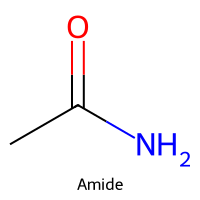

In [36]:
smiles = "CC(N)=O"
molecule_name = "Amide"
# smiles = "CC(N)=S"
# molecule_name = "Sulfinamide"
mol = rdkit.Chem.MolFromSmiles(smiles)
# ACS1996 Style Function
img = draw_molecule(
    mol,
    width=200,
    height=200,
    legend=molecule_name,
    # acs_style=True,
)
SVG(img)

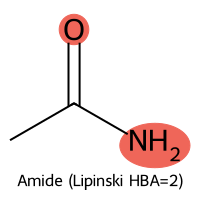

In [37]:
# Find all HBA atoms in the molecule, defined by Lipinski (All Ns and Os)
lipinski_hb_atoms = [atom for atom in mol.GetAtoms() if atom.GetAtomicNum() in (7, 8)]
lipinski_hba_atoms = [atom.GetIdx() for atom in lipinski_hb_atoms]
hba = rdMolDescriptors.CalcNumLipinskiHBA(mol)

# Highlight HBA atoms in red
img = draw_molecule(
    mol,
    width=200,
    height=200,
    legend=f"{molecule_name} (Lipinski HBA={hba})",
    highlight_atoms=lipinski_hba_atoms,
    highlight_atom_color=(0.94, 0.4, 0.35),
)
SVG(img)

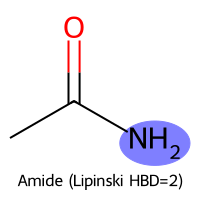

In [38]:
# Find all HBD atoms in the molecule, defined by Lipinski (All NHs and OHs)
lipinski_hbd_atoms = [atom.GetIdx() for atom in lipinski_hb_atoms if atom.GetTotalNumHs() > 0]
hbd = rdMolDescriptors.CalcNumLipinskiHBD(mol)

# Highlight HBD in blue
img = draw_molecule(
    mol,
    width=200,
    height=200,
    legend=f"{molecule_name} (Lipinski HBD={hbd})",
    highlight_atoms=lipinski_hbd_atoms,
    highlight_atom_color=(0.5, 0.5, 1.0),
)
SVG(img)

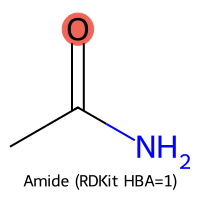

In [39]:
# Find all HBA atoms in the molecule, defined by The RDKit
HAcceptorSmarts = rdkit.Chem.MolFromSmarts(
    "[$([O,S;H1;v2]-[!$(*=[O,N,P,S])]),"
    + "$([O,S;H0;v2]),"
    + "$([O,S;-]),"
    + "$([N;v3;!$(N-*=!@[O,N,P,S])]),"
    + "$([nH0,o,s;+0])]"
)
rdkit_hba_atoms = [atom[0] for atom in mol.GetSubstructMatches(HAcceptorSmarts, uniquify=1)]
hba = Descriptors.NumHAcceptors(mol)

# Highlight HBA atoms in red
img = draw_molecule(
    mol,
    width=200,
    height=200,
    legend=f"{molecule_name} (RDKit HBA={hba})",
    highlight_atoms=rdkit_hba_atoms,
    highlight_atom_color=(0.94, 0.4, 0.35),
)
SVG(img)

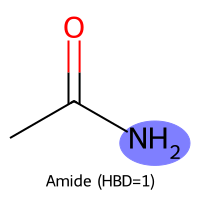

In [40]:
# Find all HBD atoms in the molecule, defined by The RDKit
HDonorSmarts = rdkit.Chem.MolFromSmarts(
    "[$([N;!H0;v3])," + "$([N;!H0;+1;v4])," + "$([O,S;H1;+0])," + "$([n;H1;+0])]"
)
rdkit_hbd_atoms = [atom[0] for atom in mol.GetSubstructMatches(HDonorSmarts, uniquify=1)]
hbd = Descriptors.NumHDonors(mol)

# Highlight HBD in blue
img = draw_molecule(
    mol,
    width=200,
    height=200,
    legend=f"{molecule_name} (HBD={hbd})",
    highlight_atoms=rdkit_hbd_atoms,
    highlight_atom_color=(0.5, 0.5, 1.0),
)
SVG(img)

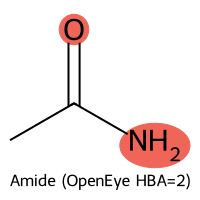

In [41]:
# Link: https://docs.eyesopen.com/python_modules/cookbook/cheminfo/acceptor-donor.html
# Link: https://docs.eyesopen.com/toolkits/python/molproptk/OEMolPropFunctions/OEGetHBondAcceptorCount.html
# Find all HBA atoms in the molecule, defined by OpenEye (SMARTS representation of ROCS, Journal of
# Computer-Aided Molecular Design, Vol. 10, pp. 607, 1996.)
HAcceptorSmarts = rdkit.Chem.MolFromSmarts(
    "[$([n;D2;+0])," + "$([N;!v4;+0])," + "$([O;+0])" + "]"
    # "[$([#8&!$(*~N~[OD1])]),"
    # + "$([#7&H0;!$([D4]);!$([D3]-*=,:[$([#7,#8,#15,#16])])]),"
    # + "$([#16])]"
)
# "[$([O,S;H1;v2]-[!$(*=[O,N,P,S])]),"
# + "$([O,S;H0;v2]),"
# + "$([O,S;-]),"
# + "$([N;v3;!$(N-*=!@[O,N,P,S])]),"
# + "$([nH0,o,s;+0])]"
oe_hba_atoms = [atom[0] for atom in mol.GetSubstructMatches(HAcceptorSmarts, uniquify=1)]
hba = len(oe_hba_atoms)

# Highlight HBA atoms in red
img = draw_molecule(
    mol,
    width=200,
    height=200,
    legend=f"{molecule_name} (OpenEye HBA={hba})",
    highlight_atoms=oe_hba_atoms,
    highlight_atom_color=(0.94, 0.4, 0.35),
)
SVG(img)

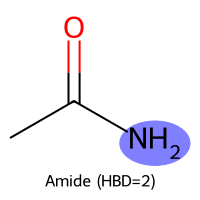

In [42]:
# Link: https://docs.eyesopen.com/toolkits/python/molproptk/OEMolPropFunctions/OEGetHBondDonorCount.html
# Find all HBD atoms in the molecule, defined by OpenEye (SMARTS representation of ROCS, Journal of
# Computer-Aided Molecular Design, Vol. 10, pp. 607, 1996.)
# Find all HBD atoms in the molecule, defined as number of hydrogen atoms on
# nitrogen, oxygen, or sulfur atoms
oe_hb_atoms = [atom for atom in mol.GetAtoms() if atom.GetAtomicNum() in (7, 8, 16)]
oe_hbd_atoms = []
hbd = 0
for atom in oe_hb_atoms:
    if atom.GetTotalNumHs() > 0:
        oe_hbd_atoms.append(atom.GetIdx())
        hbd += atom.GetTotalNumHs()

# Highlight HBD in blue
img = draw_molecule(
    mol,
    width=200,
    height=200,
    legend=f"{molecule_name} (HBD={hbd})",
    highlight_atoms=oe_hbd_atoms,
    highlight_atom_color=(0.5, 0.5, 1.0),
)
SVG(img)